# KNN

- KNN does not learn model parameters. It stores the training data and finds the nearest training samples when a new sample arrives.
- It predicts using the majority class among the K nearest neighbors.

## Euclidean Distance

$$
d(x_1,x_2) = \sqrt{\sum_{i=1}^{n}(x_{1i}-x_{2i})^2}
$$

In [1]:
# Import statements
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

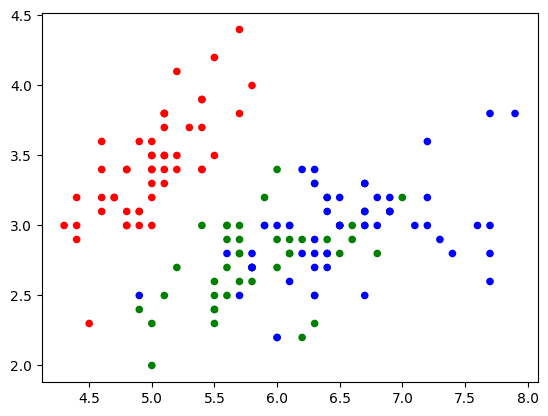

Predicted values are : [1 1 2 0 1 0 0 0 1 2 1 0 2 1 0 1 2 0 2 1 1 1 1 1 2 0 2 1 2 0] 
 Y_test values are :[1 1 2 0 1 0 0 0 1 2 1 0 2 1 0 1 2 0 2 1 1 1 1 1 2 0 2 1 2 0]
Accuracy of the KNN model is :1.0 


In [2]:
# Define eucliean distance between two datapoint
def Euclidean_Distance(x1,x2):
    return np.sqrt(((x1-x2)**2).sum())

# Define Knn class
class KNN():
    def __init__(self,k=3):
        self.k=k
    def fit(self,x,y):
        self.x_train=x
        self.y_train=y
    def predict(self,x):
        prediction=[self._predict(xx) for xx in x]
        return prediction
    def _predict(self,x):
        distance=[Euclidean_Distance(x,x_train) for x_train in self.x_train]
        indices=np.argsort(distance)[:self.k]
        label= [self.y_train[i] for i in indices]
        count={}
        for lab in label:
            count[lab]= count.get(lab,0)+1
        return max(count,key=count.get)
        
# Load the dataset iris
iris=datasets.load_iris()
x,y=iris.data,iris.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1234)
plt.scatter(x[:,0],x[:,1],c=y,cmap=ListedColormap(['r','g','b']),s=20)
plt.show()

# Make prediction
clf=KNN()
clf.fit(x_train,y_train)
prediction=np.array(clf.predict(x_test))
print(f"Predicted values are : {prediction} \n Y_test values are :{y_test}")


# Find the accuracy of KNN
accuracy= ((prediction==y_test).sum())/y_test.shape[0]
print(f"Accuracy of the KNN model is :{accuracy} ")